=== Dataset Shape ===
Rows: 891, Columns: 15

=== First 5 Rows ===
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Nul

/tmp/ipykernel_2743/936402611.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['age'].fillna(titanic['age'].median(), inplace=True)
/tmp/ipykernel_2743/936402611.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

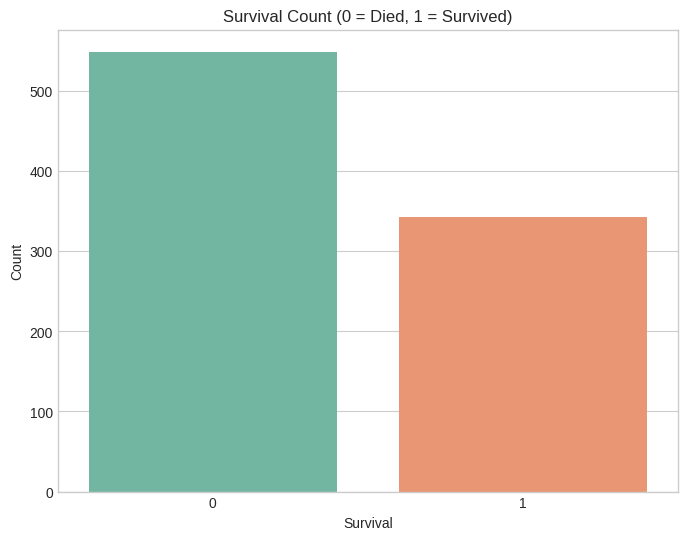

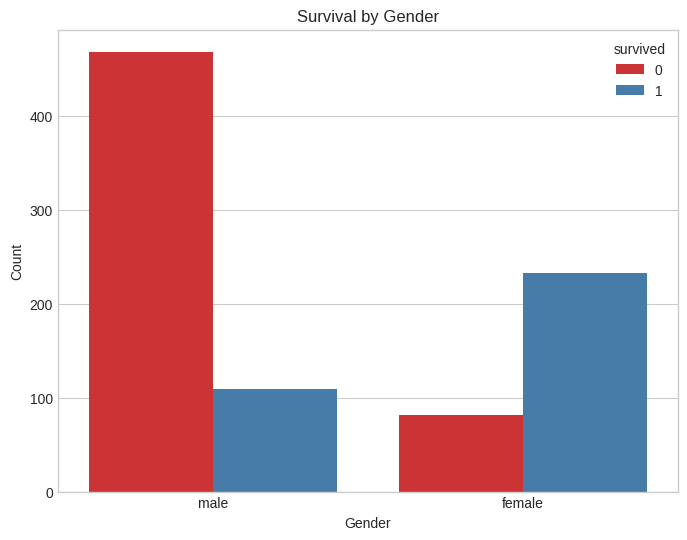

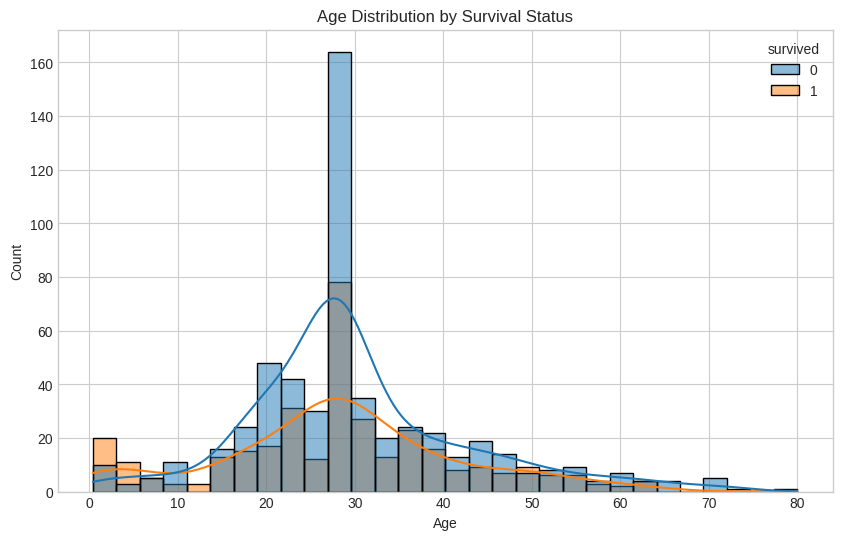

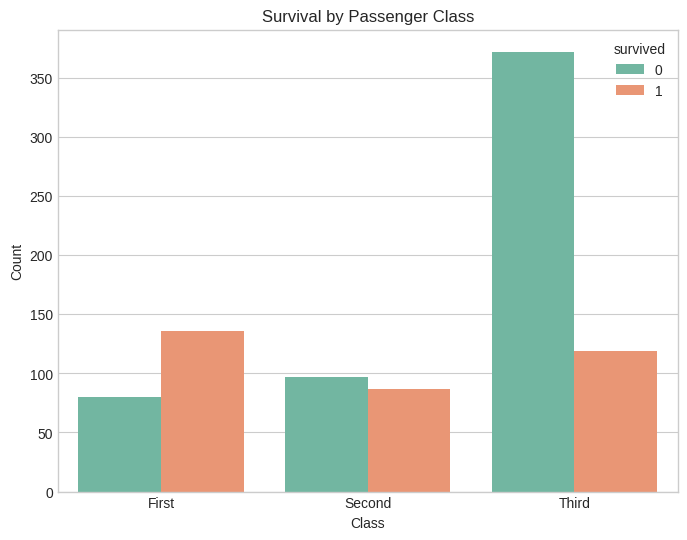

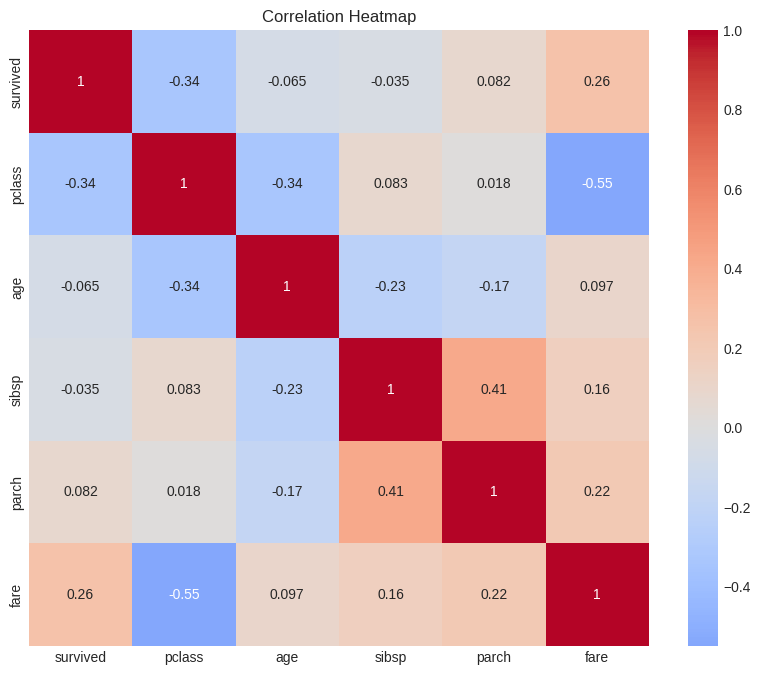


 All visualizations saved as PNG files!

=== Key Insights ===
Survival Rate: 38.38%
Female Survival Rate: 74.20%
Male Survival Rate: 18.89%


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Titanic dataset
titanic = sns.load_dataset('titanic')

# 1. Basic Dataset Information
print("=== Dataset Shape ===")
print(f"Rows: {titanic.shape[0]}, Columns: {titanic.shape[1]}")

print("\n=== First 5 Rows ===")
print(titanic.head())

print("\n=== Dataset Info ===")
print(titanic.info())

print("\n=== Statistical Summary ===")
print(titanic.describe())

print("\n=== Missing Values ===")
print(titanic.isnull().sum())

# 2. Data Cleaning - Handle missing values
titanic['age'].fillna(titanic['age'].median(), inplace=True)
titanic['embarked'].fillna(titanic['embarked'].mode()[0], inplace=True)
titanic.drop(columns=['deck'], inplace=True)

print("\n=== Missing Values After Cleaning ===")
print(titanic.isnull().sum())

# 3. Visualizations
plt.style.use('seaborn-v0_8-whitegrid')

# Plot 1: Survival Count
plt.figure(figsize=(8, 6))
sns.countplot(data=titanic, x='survived', palette='Set2')
plt.title('Survival Count (0 = Died, 1 = Survived)')
plt.xlabel('Survival')
plt.ylabel('Count')
plt.savefig('titanic_survival_count.png', dpi=300)
plt.show()

# Plot 2: Survival by Gender
plt.figure(figsize=(8, 6))
sns.countplot(data=titanic, x='sex', hue='survived', palette='Set1')
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.savefig('titanic_survival_by_gender.png', dpi=300)
plt.show()

# Plot 3: Age Distribution by Survival
plt.figure(figsize=(10, 6))
sns.histplot(data=titanic, x='age', hue='survived', kde=True, bins=30)
plt.title('Age Distribution by Survival Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.savefig('titanic_age_distribution.png', dpi=300)
plt.show()

# Plot 4: Survival by Passenger Class
plt.figure(figsize=(8, 6))
sns.countplot(data=titanic, x='class', hue='survived', palette='Set2')
plt.title('Survival by Passenger Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.savefig('titanic_survival_by_class.png', dpi=300)
plt.show()

# Plot 5: Correlation Heatmap
plt.figure(figsize=(10, 8))
numeric_cols = titanic.select_dtypes(include=[np.number]).columns
correlation = titanic[numeric_cols].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.savefig('titanic_correlation_heatmap.png', dpi=300)
plt.show()

print("\n All visualizations saved as PNG files!")

print("\n=== Key Insights ===")
print(f"Survival Rate: {(titanic['survived'].mean() * 100):.2f}%")
print(f"Female Survival Rate: {(titanic[titanic['sex']=='female']['survived'].mean() * 100):.2f}%")
print(f"Male Survival Rate: {(titanic[titanic['sex']=='male']['survived'].mean() * 100):.2f}%")